# Tugas 2 — Analisis Sinyal Suara & Noise Statis
**Mata Kuliah:** IF25-40305 Sistem Teknologi Multimedia (STM)

**Nama:** Elfa Noviana Sari
**NIM:** 123140066

**LINK REPO:** https://github.com/ElfaNovianaSari/stm-if25-40305-123140066/tree/main/02_audio_noise_statis

---

## Deskripsi Tugas

Notebook ini isinya analisis rekaman suara saya sendiri dengan membaca 2-3 kalimat berita di depan kipas angin (jarak ±0.5-1 meter), disimpan dalam .wav PCM biar tidak ada frekuensi yang hilang.

3 bagian utama :

1. Load audio + cek metadata (durasi, sample rate, jumlah sampel, min/max amplitudo).
2. Lihat audio dari 4 sisi: waveform, spektrum FFT (dBFS), spektrogram STFT, dan Mel-spektrogram.
3. Coba downsampling 48 kHz → 8 kHz dan 5 kHz dua cara: naive (x[::M], tanpa filter) vs scipy.signal.resample_poly (pakai filter anti-aliasing), lalu dibandingkan buat buktiin aliasing yang muncul kalau filternya dilewatin.

## 1. Import Library

Import seluruh library yang digunakan, **librosa** buat load audio + STFT + Mel-spectrogram, **scipy.signal** buat resampling, **numpy** buat operasi array/FFT, dan **matplotlib** buat semua plot.

In [1]:
# Import library dan atur tampilan plot supaya konsisten di semua sel
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Warna dipakai konsisten: biru = asli, merah = noise/naive, hijau = bersih/clean
C_ASLI, C_NOISE, C_BERSIH = '#0284c7', '#dc2626', '#059669'

print("Library siap dipakai.")

Library siap dipakai.


## 2. Akuisisi Audio & Ekstraksi Metadata

**audio_original.wav** adalah rekaman asli yang diambil langsung menggunakan HP. Saya pakai sr=None supaya laju sampel aslinya tidak diubah otomatis oleh librosa (default librosa resample ke 22050 Hz).

In [2]:
# Load audio dengan sample rate asli (tidak diresample otomatis), lalu cetak metadata dasarnya
AUDIO_PATH = "audio_original.wav"
y_asli, fs_asli = librosa.load(AUDIO_PATH, sr=None, mono=True)
durasi = len(y_asli) / fs_asli

print("=== METADATA AUDIO ASLI ===")
print(f"Laju sampel asli (fs)   : {fs_asli} Hz")
print(f"Jumlah sampel total     : {len(y_asli)} sampel")
print(f"Durasi rekaman          : {durasi:.3f} detik")
print(f"Amplitudo minimum       : {y_asli.min():.4f}")
print(f"Amplitudo maksimum      : {y_asli.max():.4f}")
print(f"Rata-rata RMS sinyal    : {np.sqrt(np.mean(y_asli**2)):.4f}")

=== METADATA AUDIO ASLI ===
Laju sampel asli (fs)   : 48000 Hz
Jumlah sampel total     : 574400 sampel
Durasi rekaman          : 11.967 detik
Amplitudo minimum       : -0.6414
Amplitudo maksimum      : 0.6274
Rata-rata RMS sinyal    : 0.0772


**Hasil :** untuk durasi dari audionya sekitar ±12 detik pada 48.000 Hz. RMS keseluruhan sinyal (0.077) jauh lebih kecil dari amplitudo puncaknya (0.63), tanda kalau sebagian besar durasi rekaman itu level suaranya rendah/sedang, dan cuma beberapa bagian saja yang benar-benar keras (biasanya kata-kata yang saya tekankan waktu baca berita).

## 3. Domain Waktu — Waveform

Saya plot waveform, lalu tandai satu titik paling "sepi" (representasi noise floor kipas doang) dan satu titik paling "ramai" (representasi suara aktif). Titik ini dicari otomatis lewat RMS per blok 0.1 detik.

Jeda paling sepi (noise floor)  : sekitar detik 0.00
Bagian paling ramai (vokal)     : sekitar detik 6.50


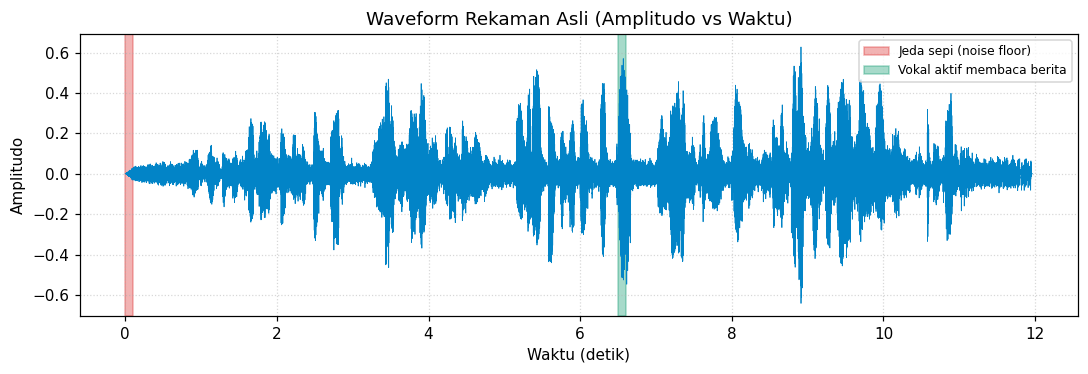

In [3]:
# Hitung RMS tiap blok 0.1 detik, lalu cari blok paling sepi (noise floor) dan paling ramai (vokal aktif)
blok_dur = 0.1
n_blok = int(blok_dur * fs_asli)  # jumlah sampel per blok 0.1 detik

# pecah sinyal jadi blok-blok kecil, hitung RMS tiap blok -> RMS tinggi = keras, RMS rendah = pelan/sepi
rms_per_blok = [(i / fs_asli, np.sqrt(np.mean(y_asli[i:i + n_blok]**2)))
                for i in range(0, len(y_asli) - n_blok, n_blok)]
waktu_blok, nilai_rms = map(np.array, zip(*rms_per_blok))

# ambil waktu blok dengan RMS terkecil (noise floor) dan terbesar (vokal paling keras)
t_sepi = waktu_blok[np.argmin(nilai_rms)]
t_ramai = waktu_blok[np.argmax(nilai_rms)]
print(f"Jeda paling sepi (noise floor)  : sekitar detik {t_sepi:.2f}")
print(f"Bagian paling ramai (vokal)     : sekitar detik {t_ramai:.2f}")

# plot waveform penuh, lalu tandai kedua area tadi dengan kotak warna transparan
t_asli = np.arange(len(y_asli)) / fs_asli
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t_asli, y_asli, color=C_ASLI, lw=0.5)
ax.axvspan(t_sepi, t_sepi + blok_dur, color=C_NOISE, alpha=0.35, label='Jeda sepi (noise floor)')
ax.axvspan(t_ramai, t_ramai + blok_dur, color=C_BERSIH, alpha=0.35, label='Vokal aktif membaca berita')
ax.set_title("Waveform Rekaman Asli (Amplitudo vs Waktu)")
ax.set_xlabel("Waktu (detik)"); ax.set_ylabel("Amplitudo")
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

**Hasil:** Berdasarkan waveform, bagian paling sepi terdapat di awal rekaman, sebelum pembacaan berita dimulai. Bagian dengan amplitudo paling tinggi terlihat pada kata yang diucapkan dengan lebih keras.

Secara umum, pola waveform mengikuti suara yang diucapkan. Amplitudo meningkat pada bagian kata atau suku kata yang lebih keras. Pada bagian yang sepi, masih terlihat osilasi kecil yang menunjukkan adanya derau latar.

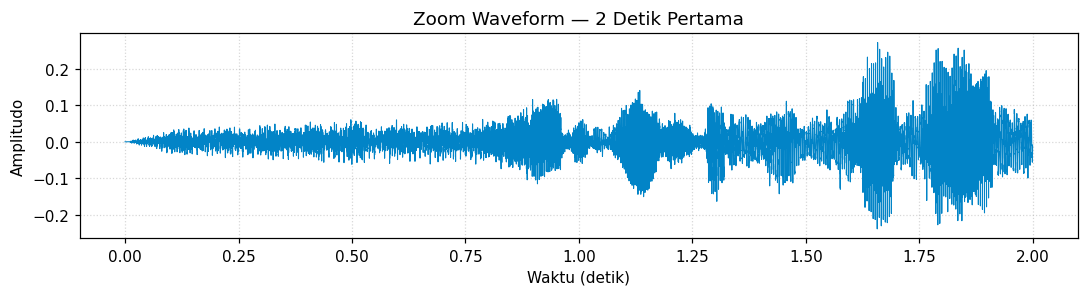

In [4]:
# Perbesar 2 detik pertama supaya transisi dari diam ke mulai bicara kelihatan lebih detail
zoom_dur = 2.0
n_zoom = int(zoom_dur * fs_asli)
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(t_asli[:n_zoom], y_asli[:n_zoom], color=C_ASLI, lw=0.7)
ax.set_title(f"Zoom Waveform — {zoom_dur:.0f} Detik Pertama")
ax.set_xlabel("Waktu (detik)"); ax.set_ylabel("Amplitudo")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout(); plt.show()

**Hasil:** Terlihat jelas bahwa pada 0–±0,8 detik sinyal masih rendah karena hanya terdapat noise kipas. Setelah ±0,8 detik, amplitudo meningkat saat mulai berbicara.

### 3.1 Eksperimen Tambahan: Pisahkan vs Gabungkan Segmen Hening & Vokal Aktif

Sekarang saya bandingkan langsung segmen hening (noise floor doang) dan segmen vokal aktif dengan dua cara: **dipisah** ke masing-masing panel sendiri (biar skalanya adil, sumbu Y disamakan), dan **digabung** dalam satu grafik overlay (biar langsung kelihatan bedanya di satu pandangan).

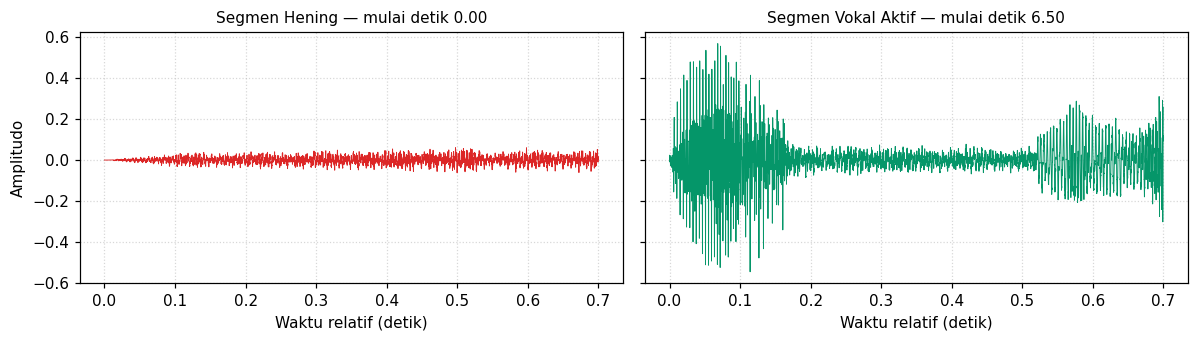

Amplitudo puncak segmen hening : 0.0620
Amplitudo puncak segmen vokal  : 0.5701
Segmen vokal ±9.2x lebih keras dibanding segmen hening


In [5]:
# Ambil segmen hening & vokal (0.7 detik, cukup singkat biar tidak kebawa transisi awal bicara), plot terpisah di dua panel dengan sumbu Y sama
dur_segmen = 0.7
n_segmen = int(dur_segmen * fs_asli)
seg_hening = y_asli[int(t_sepi * fs_asli): int(t_sepi * fs_asli) + n_segmen]
seg_vokal = y_asli[int(t_ramai * fs_asli): int(t_ramai * fs_asli) + n_segmen]
t_segmen = np.arange(n_segmen) / fs_asli

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
axes[0].plot(t_segmen, seg_hening, color=C_NOISE, lw=0.6)
axes[0].set_title(f"Segmen Hening — mulai detik {t_sepi:.2f}", fontsize=10)
axes[1].plot(t_segmen, seg_vokal, color=C_BERSIH, lw=0.6)
axes[1].set_title(f"Segmen Vokal Aktif — mulai detik {t_ramai:.2f}", fontsize=10)
for ax in axes:
    ax.set_xlabel("Waktu relatif (detik)")
    ax.grid(True, linestyle=':', alpha=0.5)
axes[0].set_ylabel("Amplitudo")
plt.tight_layout(); plt.show()

rasio = np.max(np.abs(seg_vokal)) / (np.max(np.abs(seg_hening)) + 1e-12)
print(f"Amplitudo puncak segmen hening : {np.max(np.abs(seg_hening)):.4f}")
print(f"Amplitudo puncak segmen vokal  : {np.max(np.abs(seg_vokal)):.4f}")
print(f"Segmen vokal ±{rasio:.1f}x lebih keras dibanding segmen hening")

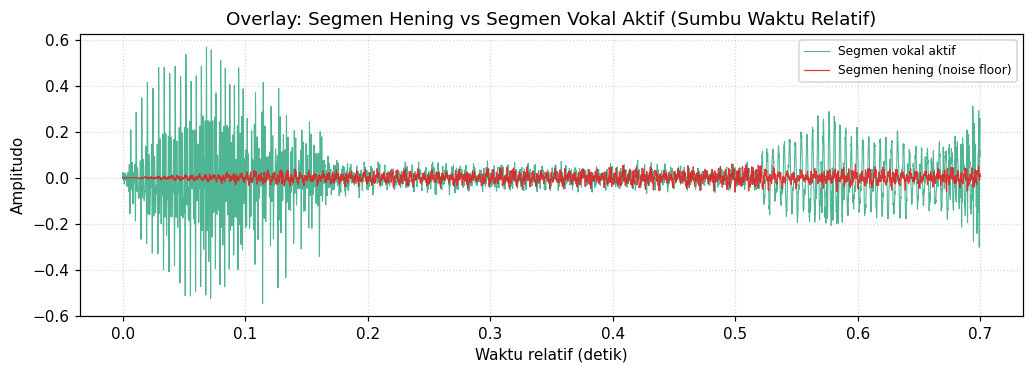

In [6]:
# Overlay kedua segmen dalam satu grafik yang sama, pakai sumbu waktu relatif supaya bisa dibandingkan langsung
fig, ax = plt.subplots(figsize=(9.5, 3.5))
ax.plot(t_segmen, seg_vokal, color=C_BERSIH, lw=0.7, alpha=0.7, label='Segmen vokal aktif')
ax.plot(t_segmen, seg_hening, color=C_NOISE, lw=0.8, alpha=0.9, label='Segmen hening (noise floor)')
ax.set_title("Overlay: Segmen Hening vs Segmen Vokal Aktif (Sumbu Waktu Relatif)")
ax.set_xlabel("Waktu relatif (detik)"); ax.set_ylabel("Amplitudo")
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Domain Frekuensi — Spektrum FFT (dBFS)

Mencari tahu frekuensi apa yang mendominasi. Fungsi spectrum_dbfs menghitung FFT per jendela dengan window Hann, dinormalisasi terhadap bobot window supaya angka dBFS-nya konsisten (tidak berubah-ubah cuma karena panjang potongan sinyal beda). Kalau sinyalnya panjang, hasil dari beberapa jendela yang overlap 50% dirata-ratakan supaya lebih stabil.

Frekuensi paling dominan pada derau statis: 175.8 Hz (-40.4 dBFS)
→ Frekuensi dominan termasuk zona: Bass


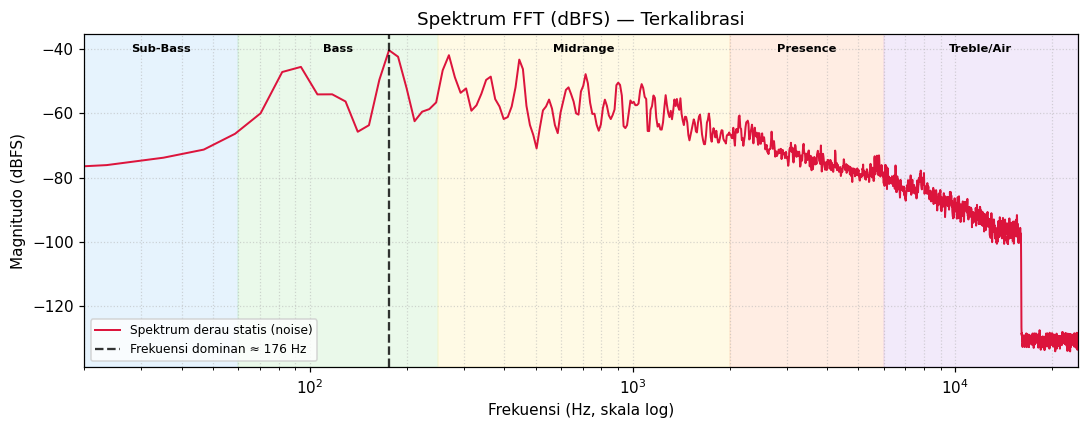

In [7]:
# Fungsi untuk menghitung spektrum FFT dalam skala dBFS (window Hann, rata-rata antar frame)
def spectrum_dbfs(x, sr, n_fft=4096, avg=True):
    x = np.asarray(x, dtype=float)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))
    w = signal.get_window("hann", n_fft, fftbins=True)
    hop = n_fft // 2 if avg else n_fft
    n_frame = max(1, (len(x) - n_fft) // hop + 1)
    akumulasi = np.zeros(n_fft // 2 + 1)
    for i in range(n_frame):
        seg = x[i * hop: i * hop + n_fft]
        if len(seg) < n_fft:
            break
        akumulasi += np.abs(np.fft.rfft(seg * w))
    magnitudo = akumulasi / n_frame / (np.sum(w) / 2)
    db = 20 * np.log10(magnitudo + 1e-12)
    freqs = np.fft.rfftfreq(n_fft, d=1 / sr)
    return freqs, db

# Hitung FFT dan spektrum dalam skala dBFS dari segmen hening (noise floor)
freqs_noise, db_noise = spectrum_dbfs(seg_hening, fs_asli, n_fft=4096, avg=True)

# Cari frekuensi dominan (puncak magnitudo tertinggi, abaikan <20Hz)
mask_valid = freqs_noise > 20
freq_dominan = freqs_noise[mask_valid][np.argmax(db_noise[mask_valid])]
mag_dominan = db_noise[mask_valid].max()

print(f"Frekuensi paling dominan pada derau statis: {freq_dominan:.1f} Hz "
      f"({mag_dominan:.1f} dBFS)")

# Definisi zona frekuensi (buat pewarnaan background saja)
ZONA = [
    (20,    60,   '#cfe8fc', 'Sub-Bass'),
    (60,    250,  '#d6f5d6', 'Bass'),
    (250,   2000, '#fff6cc', 'Midrange'),
    (2000,  6000, '#ffdcc9', 'Presence'),
    (6000,  fs_asli / 2, '#e6d6f7', 'Treble/Air'),
]

zona_dominan = next(label for f_lo, f_hi, _, label in ZONA if f_lo <= freq_dominan < f_hi)
print(f"→ Frekuensi dominan termasuk zona: {zona_dominan}")

# Visualisasi spektrum derau statis dengan latar zona frekuensi
fig, ax = plt.subplots(figsize=(10, 4))

y_min, y_max = db_noise[1:].min() - 5, db_noise[1:].max() + 5

for f_lo, f_hi, warna, label in ZONA:
    ax.axvspan(f_lo, f_hi, color=warna, alpha=0.5)
    ax.text(np.sqrt(f_lo * min(f_hi, fs_asli / 2)), y_max - 3, label,
            fontsize=7.5, fontweight='bold', ha='center', va='top')

ax.semilogx(freqs_noise[1:], db_noise[1:], color='crimson', lw=1.3,
            label='Spektrum derau statis (noise)')
ax.axvline(freq_dominan, color='black', linestyle='--', alpha=0.8,
           label=f'Frekuensi dominan ≈ {freq_dominan:.0f} Hz')

ax.set_xlim(20, fs_asli / 2)
ax.set_ylim(y_min, y_max)
ax.set_title("Spektrum FFT (dBFS) — Terkalibrasi")
ax.set_xlabel("Frekuensi (Hz, skala log)")
ax.set_ylabel("Magnitudo (dBFS)")
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

**Hasil:** Grafik spektrum FFT (dBFS) pada bagian hening menunjukkan bahwa derau kipas lebih banyak berada pada frekuensi rendah. Puncak magnitudo terlihat pada zona Bass, kemudian magnitudo menurun secara bertahap ketika frekuensi meningkat.

Berdasarkan pembagian zona frekuensi, derau kipas paling dominan pada rentang Sub-Bass hingga Bass. Sementara itu, pada zona Presence hingga Treble/Air, magnitudo terlihat lebih rendah dan relatif stabil.

## 5. Waktu-Frekuensi — Spektrogram STFT

Spektrum FFT sebelumnya hanya menunjukkan distribusi frekuensi secara rata-rata sepanjang rekaman, sehingga perubahan karakteristik sinyal terhadap waktu belum dapat diamati. Spektrogram STFT digunakan untuk melihat distribusi energi pada setiap frekuensi dari waktu ke waktu, dengan sumbu X menunjukkan waktu, sumbu Y menunjukkan frekuensi, dan intensitas warna menunjukkan besar energi sinyal. Noise yang bersifat relatif konstan akan terlihat sebagai pita horizontal yang berlangsung secara kontinu, baik ketika terdapat aktivitas vokal maupun ketika rekaman berada dalam kondisi hening.

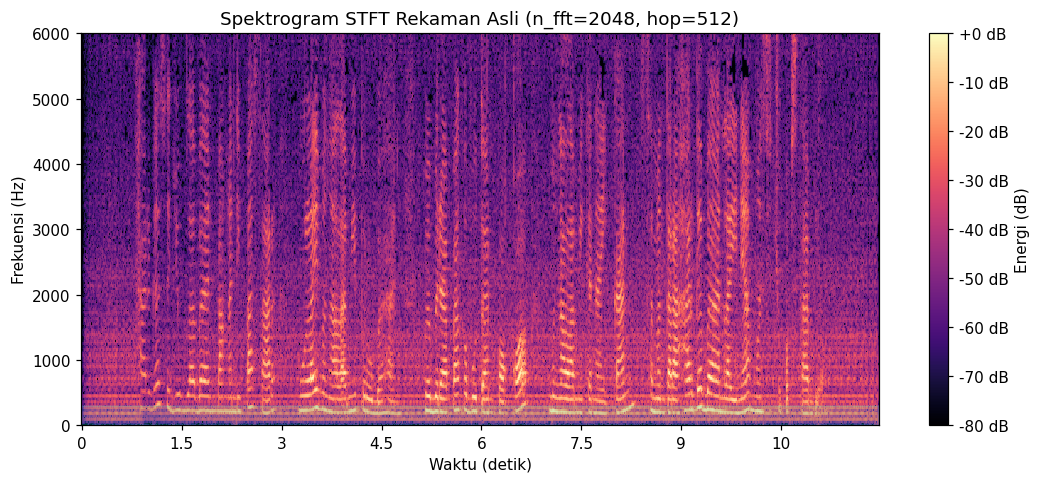

In [8]:
# Hitung STFT dari audio asli, lalu plot spektrogramnya dalam skala dB
N_FFT, HOP = 2048, 512
S_asli = np.abs(librosa.stft(y_asli, n_fft=N_FFT, hop_length=HOP))
S_db = librosa.amplitude_to_db(S_asli, ref=np.max)

fig, ax = plt.subplots(figsize=(10, 4.5))
img = librosa.display.specshow(S_db, sr=fs_asli, hop_length=HOP, n_fft=N_FFT,
                                x_axis='time', y_axis='linear', ax=ax, cmap='magma')
ax.set_ylim(0, 6000)
ax.axhspan(0, 300, color='cyan', alpha=0.15)
ax.set_title(f"Spektrogram STFT Rekaman Asli (n_fft={N_FFT}, hop={HOP})")
ax.set_xlabel("Waktu (detik)"); ax.set_ylabel("Frekuensi (Hz)")
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Energi (dB)')
plt.tight_layout(); plt.show()

**Hasil:** Spektrogram STFT memperlihatkan adanya pita energi yang cukup terang dan berlangsung secara kontinu pada rentang frekuensi rendah sepanjang durasi rekaman. Pita ini tetap tampak baik pada bagian yang hening maupun saat pembicaraan berlangsung, sehingga dapat diidentifikasi sebagai komponen derau kipas yang relatif konstan terhadap waktu.

Sebaliknya, pada rentang frekuensi yang lebih tinggi, pola energi tampak berubah-ubah mengikuti aktivitas berbicara, muncul dan menghilang sesuai dengan pengucapan kata. Perbedaan pola inilah yang secara visual membedakan derau latar yang menetap dari komponen suara manusia yang dinamis.


### 5.1 Trade-off Resolusi: 3 Skema Pemotongan Jendela

Ukuran jendela (n_fft) itu selalu tarik-menarik: jendela panjang bikin frekuensi terbaca tajam tapi waktu jadi kabur, jendela pendek sebaliknya. Saya coba 3 skema sekaligus di audio yang sama biar kelihatan bedanya:

- **Jendela pendek** (n_fft=256)
- **Kompromi** (n_fft=1024)
- **Jendela panjang** (n_fft=4096)

Skema                          Δf (Hz)   Resolusi waktu (ms)
Jendela pendek (n_fft=256)       187.5                   5.3
Kompromi (n_fft=1024)             46.9                  21.3
Jendela panjang (n_fft=4096)      11.7                  85.3


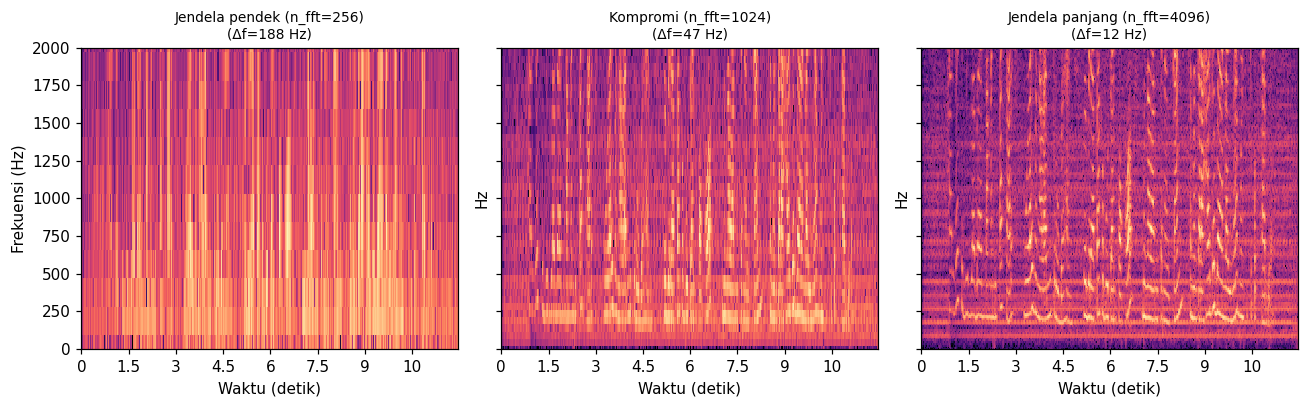

In [9]:
# Bandingkan 3 skema n_fft (pendek, kompromi, panjang) pada audio yang sama
SKEMA = [
    (256,  64,   'Jendela pendek (n_fft=256)'),
    (1024, 256,  'Kompromi (n_fft=1024)'),
    (4096, 1024, 'Jendela panjang (n_fft=4096)'),
]

print(f"{'Skema':<28}{'Δf (Hz)':>10}{'Resolusi waktu (ms)':>22}")
for n_fft_s, hop_s, judul in SKEMA:
    print(f"{judul:<28}{fs_asli/n_fft_s:>10.1f}{n_fft_s/fs_asli*1000:>22.1f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, (n_fft_s, hop_s, judul) in zip(axes, SKEMA):
    S_skema = librosa.amplitude_to_db(
        np.abs(librosa.stft(y_asli, n_fft=n_fft_s, hop_length=hop_s)), ref=np.max)
    librosa.display.specshow(S_skema, sr=fs_asli, hop_length=hop_s, n_fft=n_fft_s,
                              x_axis='time', y_axis='linear', ax=ax, cmap='magma')
    ax.set_ylim(0, 2000)
    ax.set_title(f"{judul}\n(Δf={fs_asli/n_fft_s:.0f} Hz)", fontsize=9)
    ax.set_xlabel("Waktu (detik)")
axes[0].set_ylabel("Frekuensi (Hz)")
plt.tight_layout(); plt.show()

**Hasil:** Pada skema jendela pendek (kiri), pita derau kipas tampak lebih tebal dan kurang tajam akibat resolusi frekuensi yang rendah, namun perubahan suara antarwaktu terlihat lebih jelas sehingga detail tiap suku kata lebih mudah diamati.

Pada skema jendela panjang (kanan), pita derau tampak jauh lebih tipis dan presisi karena resolusi frekuensinya tinggi, tetapi perubahan suara yang cepat menjadi kurang jelas akibat menurunnya resolusi waktu.

Skema jendela kompromi berada di antara keduanya, memberikan keseimbangan yang cukup baik antara ketajaman frekuensi dan kejelasan perubahan waktu, sehingga skema ini dipilih untuk digunakan pada analisis-analisis berikutnya.

## 6. Skala Perseptual — Mel-Spektrogram

Mel-spektrogram mengubah representasi frekuensi ke skala Mel, yaitu skala yang dirancang untuk mendekati persepsi pendengaran manusia. Pada skala ini, frekuensi rendah direpresentasikan lebih detail, sedangkan jarak antarfrekuensi semakin dipadatkan pada frekuensi yang lebih tinggi. Dengan demikian, karakteristik suara manusia, terutama pada rentang sekitar 100–4.000 Hz, dapat terlihat lebih jelas dibandingkan representasi pada skala frekuensi linear.

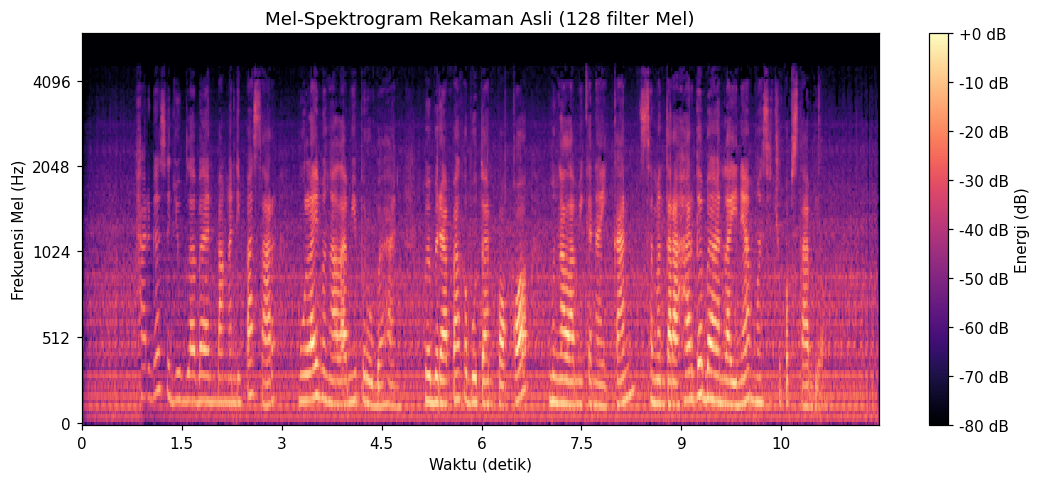

In [10]:
# Hitung Mel-spectrogram (representasi power, jadi pakai power_to_db) lalu plot
N_MELS = 128
S_mel = librosa.feature.melspectrogram(y=y_asli, sr=fs_asli, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

fig, ax = plt.subplots(figsize=(10, 4.5))
img = librosa.display.specshow(S_mel_db, sr=fs_asli, hop_length=HOP, n_fft=N_FFT,
                                x_axis='time', y_axis='mel', fmax=6000, ax=ax, cmap='magma')
ax.set_title(f"Mel-Spektrogram Rekaman Asli ({N_MELS} filter Mel)")
ax.set_xlabel("Waktu (detik)"); ax.set_ylabel("Frekuensi Mel (Hz)")
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Energi (dB)')
plt.tight_layout(); plt.show()

**Hasil:** Dibandingkan dengan spektrogram linear, Mel-spektrogram menunjukkan pola formant suara yang lebih padat dan detail pada bagian frekuensi rendah. Hal ini terjadi karena skala Mel memberikan resolusi yang lebih tinggi pada frekuensi rendah dan semakin memadat pada frekuensi tinggi. Pita noise kipas juga masih terlihat sebagai lapisan tipis yang relatif menetap di bagian bawah.

Mel-spektrogram lebih sesuai untuk melihat karakteristik suara manusia karena lebih menekankan rentang frekuensi yang berkaitan dengan suara atau ucapan.

## 7. Galeri Gabungan: Satu Rekaman, Empat Dimensi Visual

Sekarang saya gabungkan keempat cara pandang di atas (waveform, spektrum FFT, spektrogram STFT, Mel-spektrogram) dalam satu gambar 2×2, semuanya dari rekaman yang sama persis. Tujuannya biar kelihatan jelas: tiap tampilan menonjolkan informasi yang tidak kelihatan di tampilan lain.

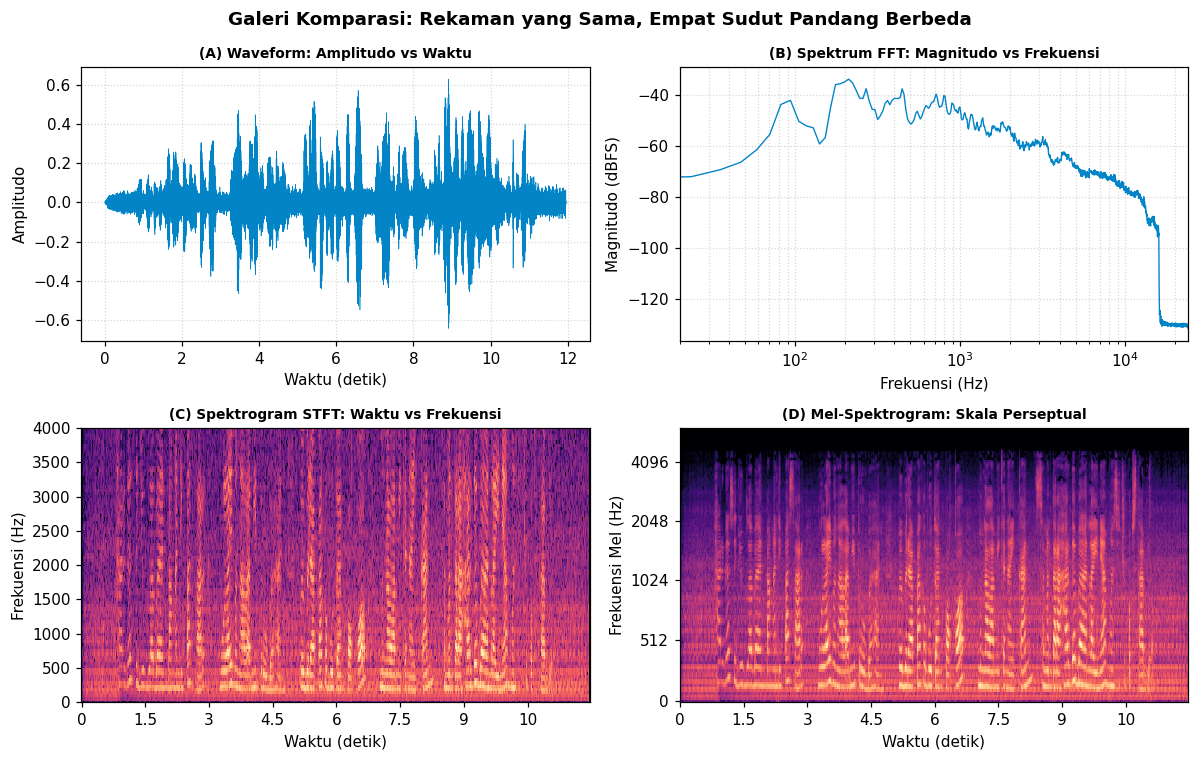

In [11]:
# Hitung dulu spektrum FFT (dBFS) untuk seluruh rekaman asli
freqs, db_full = spectrum_dbfs(y_asli, fs_asli, n_fft=4096, avg=True)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# (A) Waveform
axes[0, 0].plot(t_asli, y_asli, color=C_ASLI, lw=0.4)
axes[0, 0].set_title("(A) Waveform: Amplitudo vs Waktu", fontsize=9, fontweight='bold')
axes[0, 0].set_xlabel("Waktu (detik)"); axes[0, 0].set_ylabel("Amplitudo")
axes[0, 0].grid(True, linestyle=':', alpha=0.5)

# (B) Spektrum FFT
axes[0, 1].semilogx(freqs[1:], db_full[1:], color=C_ASLI, lw=0.9)
axes[0, 1].set_title("(B) Spektrum FFT: Magnitudo vs Frekuensi", fontsize=9, fontweight='bold')
axes[0, 1].set_xlabel("Frekuensi (Hz)"); axes[0, 1].set_ylabel("Magnitudo (dBFS)")
axes[0, 1].set_xlim(20, fs_asli / 2)
axes[0, 1].grid(True, which='both', linestyle=':', alpha=0.5)

# (C) Spektrogram STFT (pakai skema kompromi n_fft=1024)
S_gal = librosa.amplitude_to_db(np.abs(librosa.stft(y_asli, n_fft=1024, hop_length=256)), ref=np.max)
librosa.display.specshow(S_gal, sr=fs_asli, hop_length=256, n_fft=1024,
                          x_axis='time', y_axis='linear', ax=axes[1, 0], cmap='magma')
axes[1, 0].set_ylim(0, 4000)
axes[1, 0].set_title("(C) Spektrogram STFT: Waktu vs Frekuensi", fontsize=9, fontweight='bold')
axes[1, 0].set_xlabel("Waktu (detik)"); axes[1, 0].set_ylabel("Frekuensi (Hz)")

# (D) Mel-spektrogram
librosa.display.specshow(S_mel_db, sr=fs_asli, hop_length=HOP, n_fft=N_FFT,
                          x_axis='time', y_axis='mel', fmax=6000, ax=axes[1, 1], cmap='magma')
axes[1, 1].set_title("(D) Mel-Spektrogram: Skala Perseptual", fontsize=9, fontweight='bold')
axes[1, 1].set_xlabel("Waktu (detik)"); axes[1, 1].set_ylabel("Frekuensi Mel (Hz)")

fig.suptitle("Galeri Komparasi: Rekaman yang Sama, Empat Sudut Pandang Berbeda", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Hasil:** Keempat panel berasal dari rekaman yang sama, tetapi masing-masing menunjukkan informasi yang berbeda. Waveform menunjukkan perubahan volume terhadap waktu, sedangkan spektrum FFT menunjukkan frekuensi yang dominan.

Spektrogram menampilkan perubahan frekuensi terhadap waktu sehingga pola suara dan derau dapat terlihat. Sementara itu, Mel-spektrogram memberikan gambaran frekuensi yang lebih sesuai dengan cara manusia mendengar suara. Dari perbandingan tersebut, dapat dilihat bahwa setiap representasi memiliki fungsi yang berbeda dan saling melengkapi.


## 8. Pembuktian Aliasing dengan Sinyal Uji Terkontrol

Sebelum masuk ke rekaman asli, saya buktikan dulu mekanisme aliasing pakai sinyal buatan sendiri. Ada **2 percobaan** di sini, masing-masing turun ke laju sampel target yang berbeda supaya kelihatan juga bedanya ketika rasio downsample bilangan bulat vs bukan bilangan bulat:

- **Percobaan 1**: 48.000 Hz → 8.000 Hz ($M=6$, rasio bulat).
- **Percobaan 2**: 48.000 Hz → 5.000 Hz (rasio 5/48, bukan bilangan bulat), target dipilih dekat batas atas kandungan suara saya sendiri biar aliasing-nya lebih kelihatan.

### 8.1 Percobaan 1: Downsample ke 8.000 Hz

Nyquist baru = 4.000 Hz. Sinyal uji berupa komposit dua nada:

- **1000 Hz** — aman, di bawah Nyquist baru.
- **6500 Hz** — melanggar Nyquist baru. Rumus lipatan aliasing: $f_{alias} = 8000 - 6500 = 1500$ Hz, jadi harusnya menyamar jadi nada 1500 Hz palsu kalau di-downsample tanpa filter.

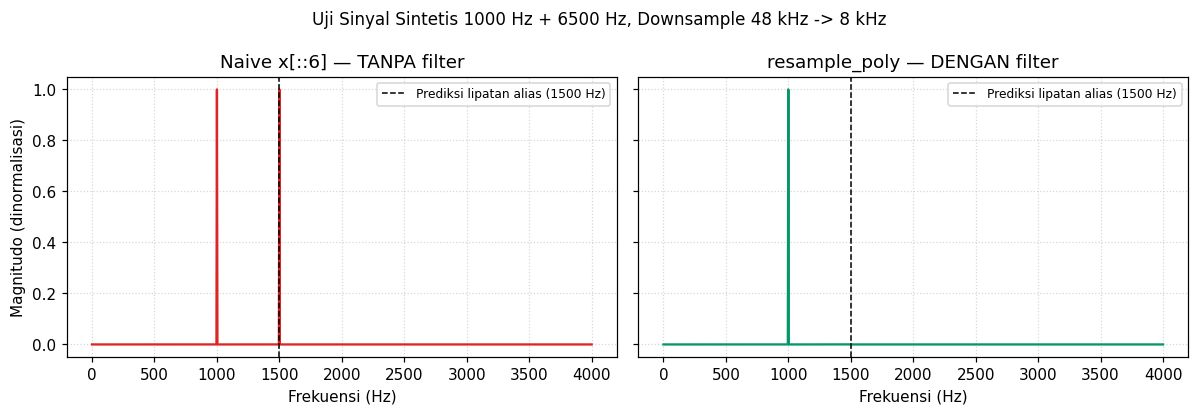

In [24]:
# Membuat sinyal uji 1 kHz + 6,5 kHz untuk melihat efek aliasing saat downsampling
fs_uji, dur_uji = 48000, 0.5
t_uji = np.linspace(0, dur_uji, int(fs_uji * dur_uji), endpoint=False)
sinyal_uji = 0.5 * np.sin(2 * np.pi * 1000 * t_uji) + 0.5 * np.sin(2 * np.pi * 6500 * t_uji)

M_uji = 6
fs_uji_target = fs_uji // M_uji
uji_naive = sinyal_uji[::M_uji]
uji_clean = signal.resample_poly(sinyal_uji, up=1, down=M_uji)

# Menghitung spektrum untuk membandingkan hasil downsampling tanpa dan dengan filter
def spektrum_sederhana(x, sr):
    n = len(x)
    spec = np.abs(np.fft.rfft(x * np.hanning(n)))
    return np.fft.rfftfreq(n, d=1 / sr), spec / spec.max()

f_naive, m_naive = spektrum_sederhana(uji_naive, fs_uji_target)
f_clean, m_clean = spektrum_sederhana(uji_clean, fs_uji_target)

# Membandingkan spektrum hasil downsampling naif dengan resample_poly
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
axes[0].plot(f_naive, m_naive, color=C_NOISE)
axes[0].set_title("Naive x[::6] — TANPA filter")
axes[1].plot(f_clean, m_clean, color=C_BERSIH)
axes[1].set_title("resample_poly — DENGAN filter")

for ax in axes:
    ax.axvline(1500, color='k', linestyle='--', lw=1, label='Prediksi lipatan alias (1500 Hz)')
    ax.set_xlabel("Frekuensi (Hz)")
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Magnitudo (dinormalisasi)")
fig.suptitle("Uji Sinyal Sintetis 1000 Hz + 6500 Hz, Downsample 48 kHz -> 8 kHz", fontsize=11)
plt.tight_layout(); plt.show()

**Hasil:** Panel kiri menunjukkan puncak tambahan di sekitar 1.500 Hz akibat aliasing, yaitu frekuensi 6.500 Hz yang terlipat setelah downsampling tanpa filter.

Pada panel kanan, puncak tersebut hampir tidak terlihat karena resample_poly menggunakan filter low-pass sebelum downsampling. Ini menunjukkan bahwa filtering diperlukan untuk mencegah munculnya frekuensi baru akibat aliasing.

### 8.2 Percobaan 2: Downsample ke 5.000 Hz

Target ini sengaja dipilih dekat batas atas kandungan suara saya sendiri (dari analisis energi kumulatif di Bagian 4, ±95-99% energi suara saya ada di bawah 1.800-3.200 Hz). Dengan Nyquist baru di 2.500 Hz, sebagian ekor frekuensi tinggi suara saya jadi berisiko aliasing — beda dengan Percobaan 1 (Nyquist 4.000 Hz) yang jauh di atas batas suara saya, jadi nyaris tidak ada yang perlu "dilipat".

Rasio 48.000/5.000 juga bukan bilangan bulat (5/48), jadi metode naive-nya tetap pakai **interpolasi linear langsung ke grid waktu baru tanpa filter anti-aliasing** — sama seperti sebelumnya, cuma target ratenya diganti.

Nyquist baru = 2.500 Hz. Sinyal uji: **1000 Hz** (aman) dan **7000 Hz** (melanggar Nyquist baru, prediksi lipatan $f_{alias} = |7000 - 5000| = 2000$ Hz).

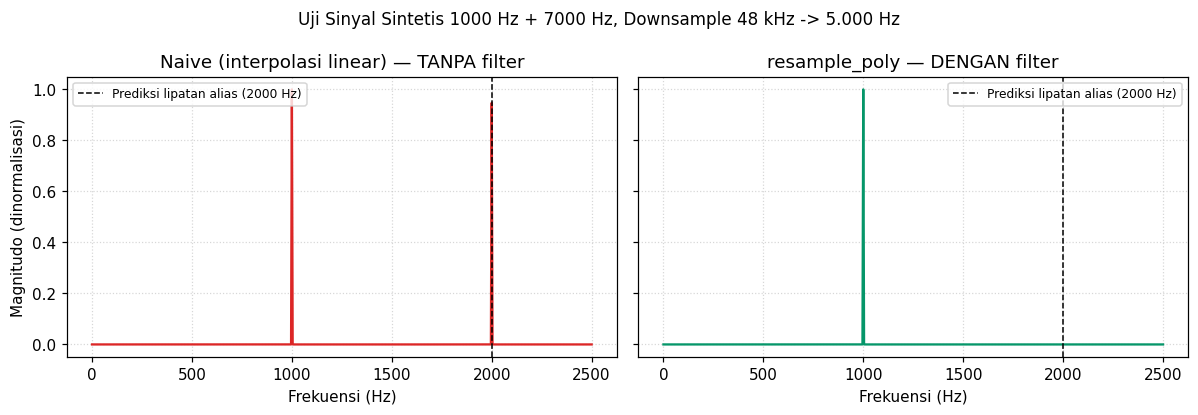

In [25]:
# Uji aliasing untuk target 5.000 Hz pakai sinyal 1000 Hz (aman) + 7000 Hz (lewat Nyquist baru)
fs_uji2, dur_uji2 = 48000, 0.5
t_uji2 = np.linspace(0, dur_uji2, int(fs_uji2 * dur_uji2), endpoint=False)
sinyal_uji2 = 0.5 * np.sin(2 * np.pi * 1000 * t_uji2) + 0.5 * np.sin(2 * np.pi * 7000 * t_uji2)

FS_TARGET_5K = 5000
UP_5K, DOWN_5K = 5, 48  # pecahan eksak 5000/48000, karena rasionya bukan bilangan bulat

# Naive: interpolasi linear langsung ke grid waktu baru, TANPA filter anti-aliasing
n_sampel_baru = int(len(sinyal_uji2) * FS_TARGET_5K / fs_uji2)
t_lama = np.arange(len(sinyal_uji2)) / fs_uji2
t_baru = np.arange(n_sampel_baru) / FS_TARGET_5K
uji2_naive = np.interp(t_baru, t_lama, sinyal_uji2)

# Benar: resample_poly dengan filter anti-aliasing
uji2_clean = signal.resample_poly(sinyal_uji2, up=UP_5K, down=DOWN_5K)

f_naive2, m_naive2 = spektrum_sederhana(uji2_naive, FS_TARGET_5K)
f_clean2, m_clean2 = spektrum_sederhana(uji2_clean, FS_TARGET_5K)

alias_prediksi = abs(7000 - FS_TARGET_5K * round(7000 / FS_TARGET_5K))  # rumus lipatan alias umum (bukan cuma selisih langsung)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
axes[0].plot(f_naive2, m_naive2, color=C_NOISE)
axes[0].set_title("Naive (interpolasi linear) — TANPA filter")
axes[1].plot(f_clean2, m_clean2, color=C_BERSIH)
axes[1].set_title("resample_poly — DENGAN filter")

for ax in axes:
    ax.axvline(alias_prediksi, color='k', linestyle='--', lw=1,
               label=f'Prediksi lipatan alias ({alias_prediksi:.0f} Hz)')
    ax.set_xlabel("Frekuensi (Hz)")
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Magnitudo (dinormalisasi)")
fig.suptitle("Uji Sinyal Sintetis 1000 Hz + 7000 Hz, Downsample 48 kHz -> 5.000 Hz", fontsize=11)
plt.tight_layout(); plt.show()

## 9. Menerapkan ke Rekaman Asli

Sekarang proses yang sama saya terapkan ke rekaman sendiri, dengan **2 percobaan** yang sama seperti Bagian 8:

- **Percobaan 1**: downsample ke 8.000 Hz ($M=6$, pas bulat).
- **Percobaan 2**: downsample ke 5.000 Hz (rasio 5/48), dipilih dekat batas atas kandungan suara saya sendiri.

### 9.1 Percobaan 1: Downsample ke 8.000 Hz

In [26]:
# Downsample rekaman asli dengan dua metode untuk membandingkan hasilnya (target 8.000 Hz)
M = 6
fs_target = fs_asli // M
y_naive = y_asli[::M]
y_clean = signal.resample_poly(y_asli, up=1, down=M)

print(f"Laju sampel target       : {fs_target} Hz")
print(f"Jumlah sampel asli       : {len(y_asli)}")
print(f"Jumlah sampel (naive)    : {len(y_naive)}")
print(f"Jumlah sampel (resample_poly) : {len(y_clean)}")

# Menyimpan rekaman asli dan dua hasil downsampling ke file WAV
sf.write("audio_original.wav", y_asli, fs_asli)
sf.write("audio_downsampled_naive_8k.wav", y_naive, fs_target)
sf.write("audio_downsampled_clean_8k.wav", y_clean, fs_target)

print("\nKetiga berkas .wav (8 kHz) berhasil disimpan di folder tugas.")

Laju sampel target       : 8000 Hz
Jumlah sampel asli       : 574400
Jumlah sampel (naive)    : 95734
Jumlah sampel (resample_poly) : 95734

Ketiga berkas .wav (8 kHz) berhasil disimpan di folder tugas.


In [27]:
# Putar ketiga versi audio untuk dengar langsung bedanya (target 8.000 Hz)
print("1. Audio asli (48.000 Hz):")
display(Audio(y_asli, rate=fs_asli))
print("2. Downsampling NAIVE x[::6] (8.000 Hz) — tanpa anti-aliasing:")
display(Audio(y_naive, rate=fs_target))
print("3. Resampling STANDAR resample_poly (8.000 Hz) — dengan anti-aliasing:")
display(Audio(y_clean, rate=fs_target))

1. Audio asli (48.000 Hz):


2. Downsampling NAIVE x[::6] (8.000 Hz) — tanpa anti-aliasing:


3. Resampling STANDAR resample_poly (8.000 Hz) — dengan anti-aliasing:


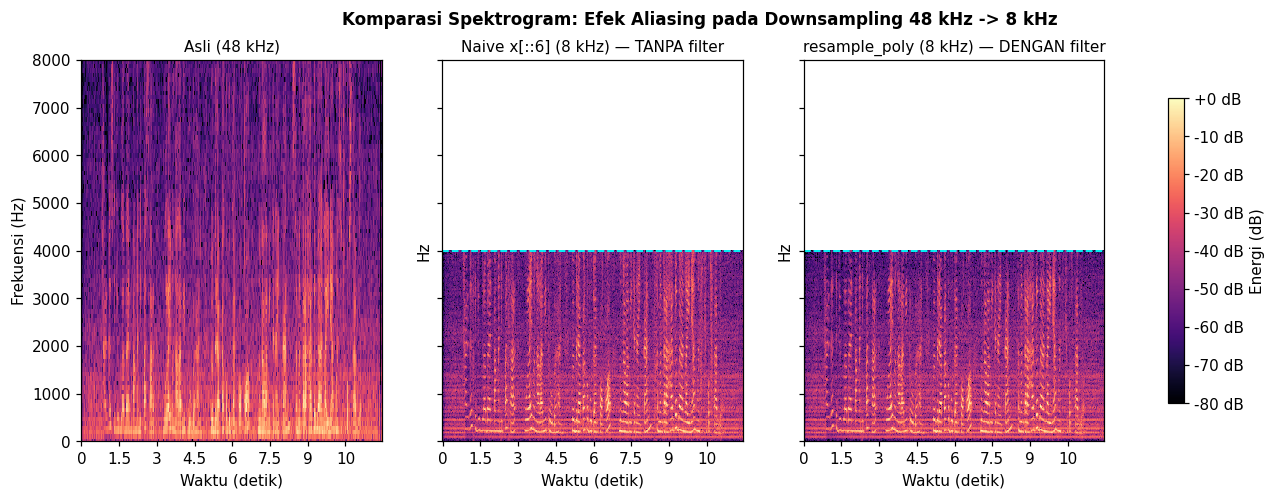

In [28]:
# Membandingkan spektrogram audio asli, naive, dan resample_poly untuk melihat efek aliasing (8.000 Hz)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
N_FFT_DS, HOP_DS = 512, 128

# Fungsi untuk menghitung dan menampilkan spektrogram setiap sinyal
def plot_spec(ax, sig, sr, judul):
    S = np.abs(librosa.stft(sig, n_fft=N_FFT_DS, hop_length=HOP_DS))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP_DS, n_fft=N_FFT_DS,
                                    x_axis='time', y_axis='linear', ax=ax, cmap='magma')
    ax.set_title(judul, fontsize=10); ax.set_xlabel("Waktu (detik)")
    return img

plot_spec(axes[0], y_asli, fs_asli, "Asli (48 kHz)")
axes[0].set_ylim(0, 8000); axes[0].set_ylabel("Frekuensi (Hz)")

# Menandai batas Nyquist 4 kHz pada hasil downsampling 8 kHz
img1 = plot_spec(axes[1], y_naive, fs_target, "Naive x[::6] (8 kHz) — TANPA filter")
axes[1].axhline(4000, color='cyan', lw=1.2, linestyle='--')

img2 = plot_spec(axes[2], y_clean, fs_target, "resample_poly (8 kHz) — DENGAN filter")
axes[2].axhline(4000, color='cyan', lw=1.2, linestyle='--')

fig.suptitle("Komparasi Spektrogram: Efek Aliasing pada Downsampling 48 kHz -> 8 kHz", fontsize=11, fontweight='bold')
fig.colorbar(img2, ax=axes, format='%+2.0f dB', label='Energi (dB)', shrink=0.8)
plt.show()

**Hasil:** Garis putus-putus cyan pada gambar menandai posisi Nyquist baru hasil downsampling ke 8.000 Hz. Secara visual, ketiga panel spektrogram tampak relatif mirip satu sama lain, yang mengindikasikan bahwa sebagian besar energi rekaman memang berada pada frekuensi yang jauh di bawah batas Nyquist tersebut, sehingga risiko aliasing pada percobaan ini tidak terlalu menonjol.

Meski demikian, pada panel naive masih dapat diamati sedikit tambahan warna atau tekstur tepat di sekitar garis batas Nyquist yang tidak muncul pada panel resample_poly. Tambahan ini mengindikasikan adanya komponen frekuensi tinggi yang terlipat ke frekuensi lebih rendah akibat tidak adanya filter anti-aliasing pada metode naive, sedangkan pada resample_poly komponen tersebut telah diredam terlebih dahulu sehingga tampilannya lebih bersih.


### 9.2 Percobaan 2: Downsample ke 5.000 Hz

In [34]:
# Downsample rekaman asli ke 5.000 Hz: naive (interpolasi linear) vs resample_poly
FS_TARGET_5K = 5000
UP_5K, DOWN_5K = 5, 48

n_sampel_baru_asli = int(len(y_asli) * FS_TARGET_5K / fs_asli)
t_lama_asli = np.arange(len(y_asli)) / fs_asli
t_baru_asli = np.arange(n_sampel_baru_asli) / FS_TARGET_5K
y_naive_5k = np.interp(t_baru_asli, t_lama_asli, y_asli)

y_clean_5k = signal.resample_poly(y_asli, up=UP_5K, down=DOWN_5K)

print(f"Laju sampel target             : {FS_TARGET_5K} Hz")
print(f"Jumlah sampel asli              : {len(y_asli)}")
print(f"Jumlah sampel (naive interp)    : {len(y_naive_5k)}")
print(f"Jumlah sampel (resample_poly)   : {len(y_clean_5k)}")

sf.write("audio_downsampled_naive_5k.wav", y_naive_5k, FS_TARGET_5K)
sf.write("audio_downsampled_clean_5k.wav", y_clean_5k, FS_TARGET_5K)
print("\nKedua berkas .wav (5.000 kHz) berhasil disimpan di folder tugas.")

# Putar untuk dengar langsung bedanya
print("1. Downsampling NAIVE (interpolasi linear, 5.000 Hz) — tanpa anti-aliasing:")
display(Audio(y_naive_5k, rate=FS_TARGET_5K))
print("2. Resampling STANDAR resample_poly (5.000 Hz) — dengan anti-aliasing:")
display(Audio(y_clean_5k, rate=FS_TARGET_5K))

Laju sampel target             : 5000 Hz
Jumlah sampel asli              : 574400
Jumlah sampel (naive interp)    : 59833
Jumlah sampel (resample_poly)   : 59834

Kedua berkas .wav (5.000 kHz) berhasil disimpan di folder tugas.
1. Downsampling NAIVE (interpolasi linear, 5.000 Hz) — tanpa anti-aliasing:


2. Resampling STANDAR resample_poly (5.000 Hz) — dengan anti-aliasing:


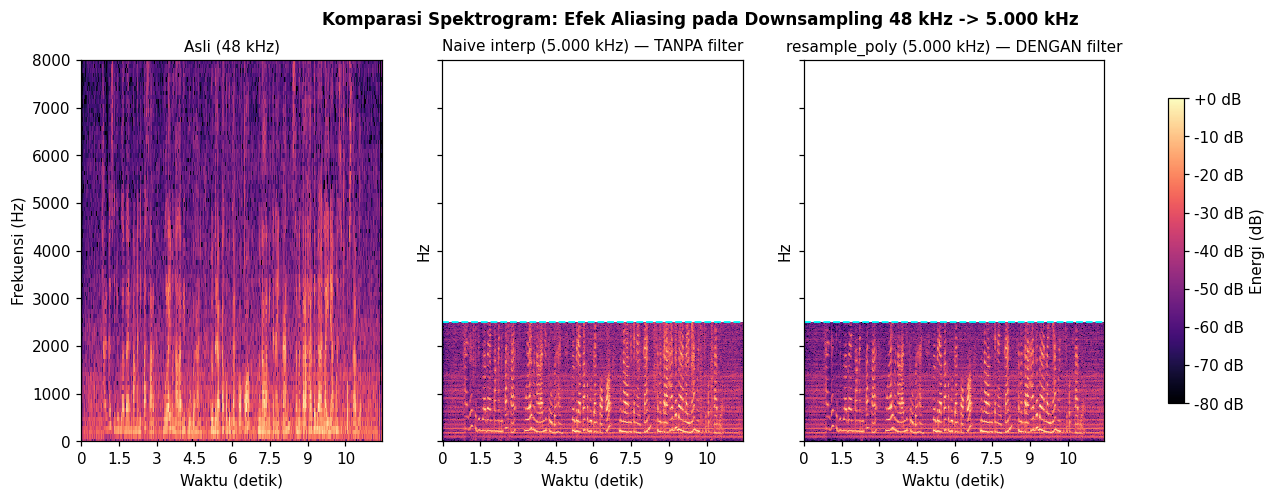

In [35]:
# Membandingkan spektrogram audio asli, naive, dan resample_poly untuk 5.000 Hz
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

plot_spec(axes[0], y_asli, fs_asli, "Asli (48 kHz)")
axes[0].set_ylim(0, 8000); axes[0].set_ylabel("Frekuensi (Hz)")

img1 = plot_spec(axes[1], y_naive_5k, FS_TARGET_5K, "Naive interp (5.000 kHz) — TANPA filter")
axes[1].axhline(FS_TARGET_5K / 2, color='cyan', lw=1.2, linestyle='--')

img2 = plot_spec(axes[2], y_clean_5k, FS_TARGET_5K, "resample_poly (5.000 kHz) — DENGAN filter")
axes[2].axhline(FS_TARGET_5K / 2, color='cyan', lw=1.2, linestyle='--')

fig.suptitle("Komparasi Spektrogram: Efek Aliasing pada Downsampling 48 kHz -> 5.000 kHz",
             fontsize=11, fontweight='bold')
fig.colorbar(img2, ax=axes, format='%+2.0f dB', label='Energi (dB)', shrink=0.8)
plt.show()

**Hasil:** Garis putus-putus cyan menunjukkan batas Nyquist baru setelah downsampling ke 5.000 Hz. Pada percobaan ini, batas Nyquist lebih dekat dengan frekuensi tinggi sehingga efek aliasing lebih mudah terlihat.

Pada panel naive, terlihat sedikit pola tambahan di atas batas Nyquist. Sementara itu, panel resample_poly terlihat lebih bersih karena menggunakan filter anti-aliasing sebelum downsampling.

Hasil ini menunjukkan bahwa downsampling tanpa filter anti-aliasing lebih berisiko menimbulkan aliasing, terutama ketika batas Nyquist berada dekat dengan frekuensi tinggi sinyal.


**KESIMPULAN:** Berdasarkan hasil analisis, setiap representasi sinyal memiliki fungsi yang berbeda. Waveform menunjukkan perubahan amplitudo terhadap waktu, FFT menunjukkan frekuensi dominan, spektrogram menunjukkan perubahan frekuensi terhadap waktu, sedangkan Mel-spektrogram memberikan gambaran frekuensi yang lebih sesuai dengan persepsi pendengaran manusia.

Pada percobaan resampling, efek aliasing lebih mudah terlihat ketika batas Nyquist baru semakin dekat dengan frekuensi tinggi sinyal. Downsampling tanpa filter anti-aliasing dapat menimbulkan pola frekuensi yang tidak diinginkan, sedangkan resample_poly dapat mengurangi efek tersebut.

Derau kipas tetap terdengar pada hasil resample_poly karena derau tersebut berada pada frekuensi rendah yang masih berada di bawah batas Nyquist. Filter anti-aliasing hanya berfungsi mengurangi frekuensi di atas batas Nyquist, bukan menghilangkan semua jenis derau.